# EEG Intent Classification — Improved Pipeline

**Project:** EEG-based intent-driven shared-control prosthetic arm  
**Classes:** idle (T0), grasp (T1), release (T2)

## Important interpretation
This notebook uses PhysioNet EEGMMIDB subject S001 as a development benchmark. In that dataset, T0 is rest, while T1/T2 are left/right hand tasks — they are **not true grasp/release labels**. The three-class result is therefore a rest-vs-two-hand-task benchmark, not proof of grasp/release decoding. The uploaded report's ~66.7% result is a different binary T1-vs-T2 experiment with 60 motor trials and no idle class.

Running the original uploaded notebook as-is reproduces approximately 56.7% accuracy on 120 valid epochs (60 idle, 32 T1, 28 T2) with its fixed seed. This revised notebook also reports a conventional CSP baseline using the safer per-run preprocessing and 0–4 s window, followed by the filter-bank model. Accuracy varies with the random fold assignment, so it reports both a fixed split and repeated 5-fold estimates.

## Improvements in this notebook
- Auto-download PhysioNet data (no hard-coded Tarun path)
- Motor strip channels (C3, Cz, C4, FC3, FC4, …)
- CSP + LDA with **fold-safe** cross-validation (no leakage)
- Filter-bank CSP: separate spatial filters for mu/beta sub-bands, concatenated before LDA
- Longer but non-overlapping epoch window (0–4.0 s) for motor-related ERD
- Shrinkage LDA for the small-sample, high-dimensional feature space


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci
from mne.decoding import CSP

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, balanced_accuracy_score

mne.set_log_level("ERROR")
plt.rcParams["figure.figsize"] = (8, 5)

# ── Config ───────────────────────────────────────────────────────────────────
DATA_PATH = "mne_data"                       # PhysioNet cache; downloads automatically
SUBJECTS = [1]                                 # add more subjects: [1,2,3,4,5]
RUNS = [3, 4, 7, 8]                            # 3,4=execution  7,8=imagery
MOTOR_CHANNELS = [
    "Fc5.", "Fc3.", "Fc1.", "Fcz.", "Fc2.", "Fc4.", "Fc6.",
    "C5..", "C3..", "C1..", "Cz..", "C2..", "C4..", "C6..",
]
TMIN, TMAX = 0.0, 4.0
FREQ_BANDS = [(8, 12), (12, 16), (16, 20), (20, 26), (26, 30)]
CV_SEEDS = list(range(10))


In [2]:
def load_subject(subject, runs):
    """Load each run separately so filtering never crosses a run boundary."""
    raws = []
    for run in runs:
        paths = eegbci.load_data(subject, [run], path=DATA_PATH, update_path=True, verbose=False)
        raw = mne.io.read_raw_edf(paths[0], preload=True, verbose=False)
        raw.pick([ch for ch in MOTOR_CHANNELS if ch in raw.ch_names])
        raws.append(raw)
    return raws


def make_epochs(raws, l_freq=8.0, h_freq=30.0, tmin=TMIN, tmax=TMAX):
    """Filter and epoch each run independently, then concatenate epochs."""
    all_epochs = []
    for raw in raws:
        filtered = raw.copy()
        filtered.filter(l_freq, h_freq, method="fir", verbose=False)
        filtered.notch_filter(50, verbose=False)
        filtered.set_eeg_reference("average", projection=True, verbose=False)
        filtered.apply_proj(verbose=False)
        events, event_id = mne.events_from_annotations(filtered, verbose=False)
        all_epochs.append(mne.Epochs(
            filtered, events,
            event_id={"idle": event_id["T0"], "grasp": event_id["T1"], "release": event_id["T2"]},
            tmin=tmin, tmax=tmax, baseline=None, preload=True,
            reject=dict(eeg=200e-6), verbose=False,
        ))
    return mne.concatenate_epochs(all_epochs)


raws = load_subject(SUBJECTS[0], RUNS)
epochs = make_epochs(raws)
y = LabelEncoder().fit_transform(epochs.events[:, 2])
print(f"S{SUBJECTS[0]:03d}: {len(epochs)} epochs | balance {np.bincount(y)}")


S001: 120 epochs | balance [60 32 28]


── CSP + LDA (3-class, fold-safe CV) ──
              precision    recall  f1-score   support

        idle       0.70      0.73      0.72        60
       grasp       0.64      0.56      0.60        32
     release       0.55      0.57      0.56        28

    accuracy                           0.65       120
   macro avg       0.63      0.62      0.63       120
weighted avg       0.65      0.65      0.65       120

Accuracy: 0.650
Balanced accuracy: 0.622


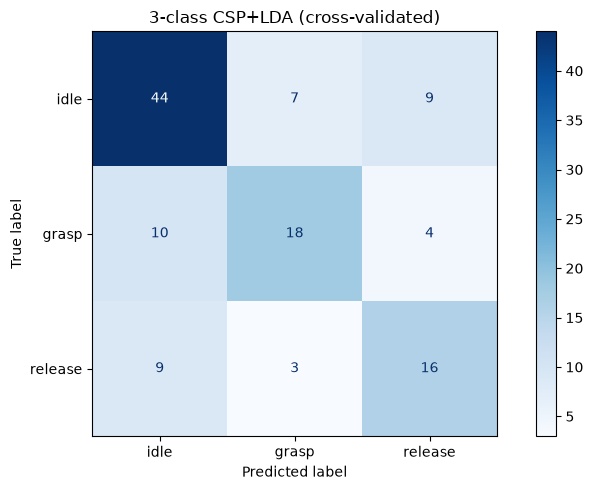

In [3]:
def csp_lda_cv_predict(X, y, n_components=6, n_splits=5, random_state=42):
    """Fold-safe CSP+LDA — CSP and LDA are refit inside each training fold."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    y_pred = np.zeros(len(y), dtype=int)

    for train_idx, test_idx in cv.split(X, y):
        csp = CSP(n_components=n_components, reg="oas", log=True, norm_trace=False)
        X_train = csp.fit_transform(X[train_idx], y[train_idx])
        X_test = csp.transform(X[test_idx])

        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearDiscriminantAnalysis()),
        ])
        clf.fit(X_train, y[train_idx])
        y_pred[test_idx] = clf.predict(X_test)

    return y_pred


X = epochs.get_data()
y_pred = csp_lda_cv_predict(X, y, random_state=42)

print("── CSP + LDA (3-class, fold-safe CV) ──")
print(classification_report(y, y_pred, target_names=["idle", "grasp", "release"]))
print(f"Accuracy: {(y_pred == y).mean():.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y, y_pred):.3f}")

ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=["idle", "grasp", "release"],
    cmap="Blues",
)
plt.title("3-class CSP+LDA (cross-validated)")
plt.tight_layout()
plt.show()


── Filter-bank CSP + shrinkage LDA (3-class, fold-safe CV) ──
              precision    recall  f1-score   support

        idle       0.72      0.73      0.73        60
       grasp       0.68      0.66      0.67        32
     release       0.61      0.61      0.61        28

    accuracy                           0.68       120
   macro avg       0.67      0.67      0.67       120
weighted avg       0.68      0.68      0.68       120

Accuracy: 0.683
Balanced accuracy: 0.666


Repeated 5-fold accuracy: 0.672 ± 0.030


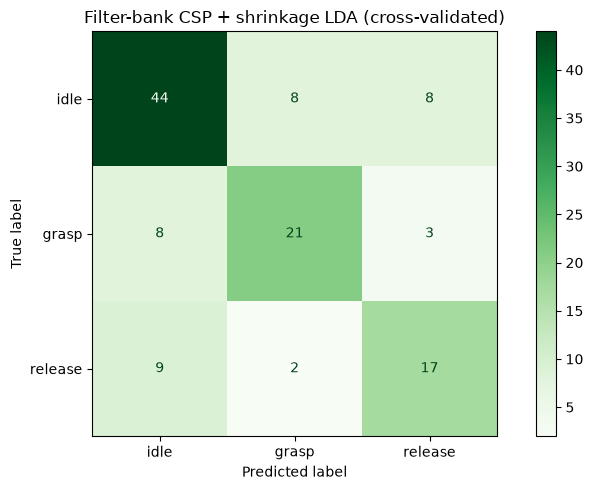

In [4]:
def filterbank_csp_lda_cv_predict(X_bands, y, n_components=4, random_state=42):
    """Fold-safe filter-bank CSP + shrinkage LDA for the three classes."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    y_pred = np.zeros(len(y), dtype=int)
    for train_idx, test_idx in cv.split(X_bands[0], y):
        train_features, test_features = [], []
        for X_band in X_bands:
            csp = CSP(n_components=n_components, reg="oas", log=True, norm_trace=False)
            train_features.append(csp.fit_transform(X_band[train_idx], y[train_idx]))
            test_features.append(csp.transform(X_band[test_idx]))
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearDiscriminantAnalysis(shrinkage="auto", solver="lsqr")),
        ])
        clf.fit(np.concatenate(train_features, axis=1), y[train_idx])
        y_pred[test_idx] = clf.predict(np.concatenate(test_features, axis=1))
    return y_pred


X_bands = []
for low, high in FREQ_BANDS:
    band_epochs = make_epochs(raws, low, high, TMIN, TMAX)
    X_bands.append(band_epochs.get_data())

y_pred_filterbank = filterbank_csp_lda_cv_predict(X_bands, y, random_state=42)
print("── Filter-bank CSP + shrinkage LDA (3-class, fold-safe CV) ──")
print(classification_report(y, y_pred_filterbank, target_names=["idle", "grasp", "release"]))
print(f"Accuracy: {(y_pred_filterbank == y).mean():.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y, y_pred_filterbank):.3f}")

repeated_scores = []
for seed in CV_SEEDS:
    pred = filterbank_csp_lda_cv_predict(X_bands, y, random_state=seed)
    repeated_scores.append((pred == y).mean())
print(f"Repeated 5-fold accuracy: {np.mean(repeated_scores):.3f} ± {np.std(repeated_scores):.3f}")

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_filterbank,
    display_labels=["idle", "grasp", "release"],
    cmap="Greens",
)
plt.title("Filter-bank CSP + shrinkage LDA (cross-validated)")
plt.tight_layout()
plt.show()


In [5]:
# Binary comparison from the report: T1 vs T2 only, with idle removed.
# This is not comparable to the three-class grasp/release/idle accuracy above.
for run_set, label in [([3, 4], "execution"), ([7, 8], "imagery")]:
    run_raws = load_subject(SUBJECTS[0], run_set)
    ep = make_epochs(run_raws, 8.0, 30.0, TMIN, TMAX)
    motor_mask = ep.events[:, 2] != 1  # T0 is encoded as 1 by MNE
    X_motor = ep.get_data()[motor_mask]
    y_motor = LabelEncoder().fit_transform(ep.events[motor_mask, 2])
    pred = csp_lda_cv_predict(X_motor, y_motor, n_components=4, random_state=42)
    print(f"{label:10s} T1-vs-T2 accuracy: {(pred == y_motor).mean():.3f}  (n={len(y_motor)})")


execution  T1-vs-T2 accuracy: 0.767  (n=30)


imagery    T1-vs-T2 accuracy: 0.667  (n=30)


## Next steps for the prosthetic arm (Emotiv branch)

1. **Record your own data** with Emotiv: idle, grasp, release — do not reuse PhysioNet left/right labels as grasp/release labels.
2. **Calibrate per user and session**; subject-specific models are more appropriate than cross-user claims.
3. **Use execution/motor imagery runs separately** during prototyping; imagery is harder.
4. **Collect more trials** — aim for 50+ epochs per class minimum and report a held-out run test.
5. **Map Emotiv channels** to nearest 10-20 system (AF3/F3/FC5/C3/C4/…).

When Emotiv `.csv` or `.edf` files are available, set `DATA_PATH` / loader accordingly and keep the same CSP pipeline.
